In [2]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from scipy.interpolate import interp1d
from collections import defaultdict

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

# Inputs

In [3]:
# species = "Rb87" # "Rb87", "K40"
species = "K40" # "Rb87", "K40"

# lattice parameters
V1064Er = 10            # 1064 lattice depth, in 1064 recoil energy
V532Er = 10             # 532 lattice depth, in 532 recoil energy
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the phase by pi for 1064 restores the original lattice
# phi12, phi23 = 0., 0.
# phi12, phi23 = -np.pi/10, np.pi/10   # split gamma QBTP along Mp-Mp4
phi12, phi23 = np.pi/4, np.pi/5   # ABCD offset - use deep 532 lattice, e.g. 10 Er for both
# phi12, phi23 = np.pi*1/3, -np.pi*1/3    # decorated triangular lattice (2/3 also works)
# phi12, phi23 = -np.pi*1/3, 0    # stripe
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 5             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 5         # inclusive


A few commonly used q-space trajectories.

In [4]:
# (most common) gamma, K, M, gamma
qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Mp4/E9c.k_lw, E9c.Gp/E9c.k_lw'
x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$']

# M, gamma, K, M
# qverts_str = 'E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw'
# x_ticklist = ["M", '$\Gamma$', 'K', 'M']

# K', gamma, K, M, gamma
# qverts_str = 'E9c.Kp4/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
# x_ticklist = ["K'", '$\Gamma$', 'K', 'M', '$\Gamma$']

# gamma, K, M, gamma, M
# qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Mp4/E9c.k_lw'
# x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$', 'M']

# 1st BZ edges
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'

# Small square around gamma
# qverts_str = 'np.array([0.4, -0.4]), np.array([0.4, 0.4]), np.array([-0.4, 0.4]), np.array([-0.4, -0.4]), np.array([0.4, -0.4])'

# qx = 0, within 1st BZ
# qverts_str = 'E9c.Kp3/E9c.k_lw, E9c.Kp6/E9c.k_lw'
# x_ticklist = ["K'", 'K']

# qx = 0, gamma - gamma
# qverts_str = 'E9c.Gp/E9c.k_lw, 2 * E9c.Kp6/E9c.k_lw'
# x_ticklist = ['$\Gamma$', '2K']

# qy = 0
# qverts_str = 'E9c.Mp/E9c.k_lw, E9c.Mp4/E9c.k_lw'
# x_ticklist = ["M'", 'M']

save_results = False

# Initialization
## Units

In [5]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [6]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

In [7]:
def MinimumGap(e_values, band1, band2):
    """Prints the position and energy of the minimum gap.
    
    Example: MinimumGap(e_values,2,3)
    Should be slightly enhanced to return something
    """
    gaps = e_values[:, band2] - e_values[:, band1]
    print('The minimum band gap between band{} and band{} is {} kHz, happening at the {} (python index) q evaluated' \
          .format(band1, band2, gaps.min() * f_unit / 1e3 / (2 * np.pi), gaps.argmin()))

# Real space plots

In [8]:
a_tri_um = E9c.a_sw_tri * 1e6
uc_vertices = [a_tri_um * np.array([-np.sqrt(3) * 4 / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, 1]),
               a_tri_um * np.array([np.sqrt(3) / 3, 0]),
               a_tri_um * np.array([-np.sqrt(3) / 2, -1]),]
uc_vertices.append(uc_vertices[0])

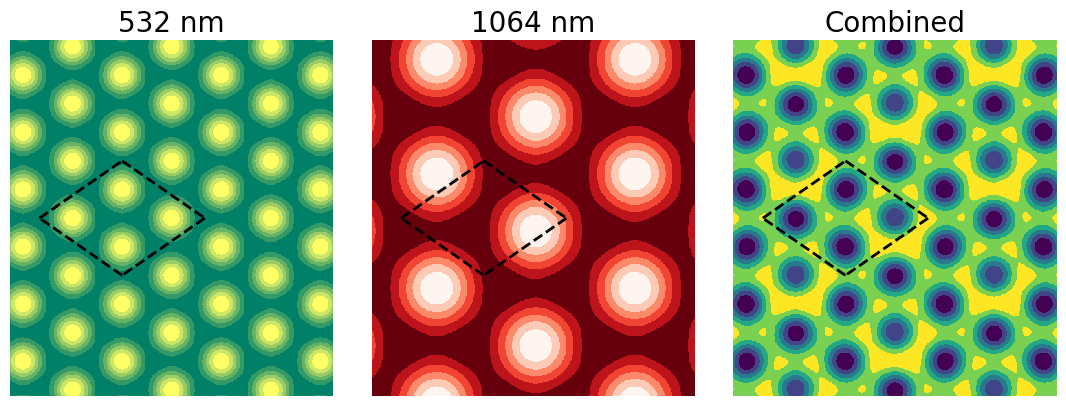

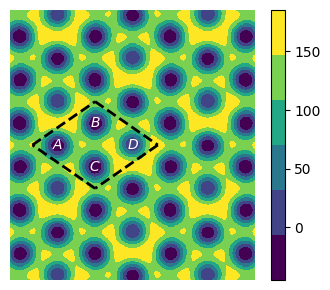

In [ ]:
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6
x_real_um = np.linspace(-1, 1, 500)
y_real_um = np.linspace(-1.1, 1.1, 500)

pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real

fig_real, (ax_532, ax_1064, ax_super) = plt.subplots(1, 3, figsize = (11, 4))
fig_ABCD, ax_ABCD = plt.subplots(1, 1, figsize = (3.5, 3))
# fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")

for ax, V_real, ax_title, cmap_str in zip([ax_532, ax_1064, ax_super, ax_ABCD],
                                        [V_532_real, V_1064_real, V_super_real, V_super_real],
                                        ["532 nm", "1064 nm", "Combined", ""],
                                        ["summer_r", 'Reds_r', "viridis", "viridis"],):
    ax.set_aspect("equal")
    im = ax.pcolormesh(x_real_um, y_real_um, V_real, cmap = cmap_str, rasterized = True)
    # ax.scatter(0, 0, color = 'red', marker = '+', s = 50)   # origin
    # ax.scatter(-a_tri_um * 2 / np.sqrt(3), 0, color = 'cyan', marker = 'x', s = 50)   # 1064 site
    
    # add unit cell
    for p1, p2 in zip(uc_vertices[:-1], uc_vertices[1:]):
        x1, y1 = p1
        x2, y2 = p2
        ax.plot([x1, x2], [y1, y2], color = "black", ls = "--", lw = 2)

    ax.set_title(ax_title, fontsize = 20)
    ax.axis("off")
    # fig_real.colorbar(im, ax = ax)

fig_ABCD.colorbar(im, ax = ax_ABCD)

# add sublattice labels
ax_ABCD.text(-a_tri_um * np.sqrt(3), 0, r"$A$", size = 10, color = "white",
            ha = "center", va = "center")
ax_ABCD.text(-a_tri_um * np.sqrt(3) / 2, a_tri_um / 2, r"$B$", size = 10, color = "white",
            ha = "center", va = "center")
ax_ABCD.text(-a_tri_um * np.sqrt(3) / 2, - a_tri_um / 2, r"$C$", size = 10, color = "white",
            ha = "center", va = "center")
ax_ABCD.text(0, 0, r"$D$", size = 10, color = "white",
            ha = "center", va = "center")

fig_real.tight_layout()
fig_ABCD.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
band_struc_full_path = Path(thesis_fig_path, "ABCD_V_of_r.pdf")
# fig_ABCD.savefig(band_struc_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')

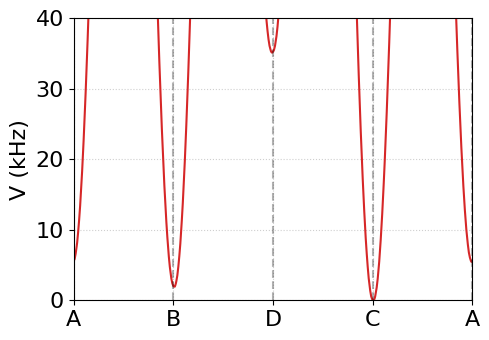

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# 1. Define the spatial locations of the four sublattices 
A_loc = np.array([-a_tri_um * np.sqrt(3), 0])
B_loc = np.array([-a_tri_um * np.sqrt(3) / 2, a_tri_um / 2])
C_loc = np.array([-a_tri_um * np.sqrt(3) / 2, -a_tri_um / 2])
D_loc = np.array([0, 0])

# 2. Define the path sequence
path_points = [A_loc, B_loc, D_loc, C_loc, A_loc]
path_labels = ['A', 'B', 'D', 'C', 'A']

# 3. Create a 2D interpolator for the combined real-space potential
interp_func = RegularGridInterpolator((y_real_um, x_real_um), V_super_real, bounds_error=False, fill_value=None)

# 4. Generate points along the piecewise line
pts_per_segment = 200
path_x = []
path_y = []
path_dist = []
tick_distances = [0]
current_dist = 0

for i in range(len(path_points) - 1):
    p1 = path_points[i]
    p2 = path_points[i+1]
    
    t = np.linspace(0, 1, pts_per_segment, endpoint=(i == len(path_points) - 2))
    seg_x = p1[0] + t * (p2[0] - p1[0])
    seg_y = p1[1] + t * (p2[1] - p1[1])
    
    segment_length = np.linalg.norm(p2 - p1)
    seg_dist = current_dist + t * segment_length
    
    path_x.extend(seg_x)
    path_y.extend(seg_y)
    path_dist.extend(seg_dist)
    
    current_dist += segment_length
    tick_distances.append(current_dist)

# 5. Evaluate the potential along the generated path points
query_points = np.column_stack((path_y, path_x))
pot_along_path = interp_func(query_points)

# ==========================================
# NEW: Shift minimum to 0 and convert to kHz
# ==========================================
# Set the minimum energy along this specific path to 0
pot_shifted = pot_along_path - np.min(pot_along_path)

# Convert from natural units to kHz 
# (E2kHz is already defined earlier in your notebook as E_unit / E9c.hnobar / 1e3)
pot_kHz = pot_shifted * E2kHz
# ==========================================

# 6. Plot the results
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(path_dist, pot_kHz, lw=1.5, color='#d62728')

# Overlay vertical lines at the sublattice centers
for td in tick_distances:
    ax.axvline(td, color='black', linestyle='--', alpha=0.3)

# Configure the custom x-axis ticks
ax.set_xticks(tick_distances)
ax.set_xticklabels(path_labels, fontsize=16)

# Updated Y-axis label
ax.set_ylabel('V (kHz)', fontsize=16)
# ax.set_title('Real-Space Potential along Sublattice Path', fontsize=16)
ax.set_xlim(0, current_dist)
ax.set_ylim(0, 40)
ax.set_yticks([0, 10, 20, 30, 40], [0, 10, 20, 30, 40], fontsize=16)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Optional: To save this specifically for your thesis
# fig.savefig(Path(thesis_fig_path, "ABCD_real_potential_cut_kHz.pdf"), facecolor="none", dpi=300, bbox_inches='tight')

# Finding Bloch states and band energies

In [10]:
dq = 0.01
rq_circ = 0.65625

Total number of points = 234
--- 1.5414986610412598 seconds ---


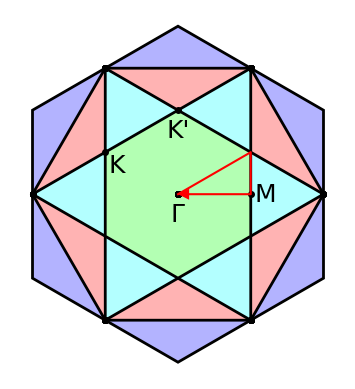

In [11]:
start_time = time.time()

# Generate qset

# Piecewise linear
# number of points sampled between two points (can be an array specifying each path, or just one number for all)
num_points = np.array([int(np.linalg.norm(p2 - p1) / dq) for p1, p2 in zip(qverts_arr[:-1], qverts_arr[1:])])
index_points = np.hstack((np.array([0]), np.cumsum(num_points))) - np.arange(len(num_points) + 1)
qsets, xq = bsc.find_qset_piecewise_linear(qverts_arr, num_points)

# Circular
# num_points = int(2. * np.pi * rq_circ / dq)
# qsets, xq = bsc.find_qset_circle(E9c.Gp/E9c.k_lw, rq_circ, theta_init = np.pi + 0.001, pt_num = num_points)

e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

# find non-interacting solution
print("Total number of points = {0}".format(len(qsets)))
fig_BZ, ax_BZ = plt.subplots(1, 1)#, figsize = (20, 16))
ax_BZ.axis("off")
bsc.PlotBZSubplot(ax_BZ,
                #   add_q_pts = True,
                  label_sym_pts = True,
                #   fontsize = 26, s_q_pt = 36
                  )
bsc.plot_qset(ax_BZ, qset = qsets, qset_type = 'circle')
Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)
ax_BZ.set_xlim(-2, 2)
ax_BZ.set_ylim(-2.2, 2.2)

# Fix the gauge of eigenstates using parallel transport
e_states_fixed = bsc.fix_gauge_parallel_transport_1d(e_states, flip_gauge_for_bands = [0])
for i in range(len(qsets)):
    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
print("--- {0} seconds ---".format((time.time() - start_time)))

In [12]:
if not np.all(np.isreal(e_values)):
    logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
e_values = e_values.astype(np.double)

C:\Users\ken92\AppData\Local\Temp\ipykernel_27232\1078986975.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  e_values = e_values.astype(np.double)


## Plots

### Band structure

In [13]:
# E_R_axis = "532"
E_R_axis = "1064"

In [14]:
E_R_conv = 1
if E_R_axis == "1064":
    E_R_conv = 4

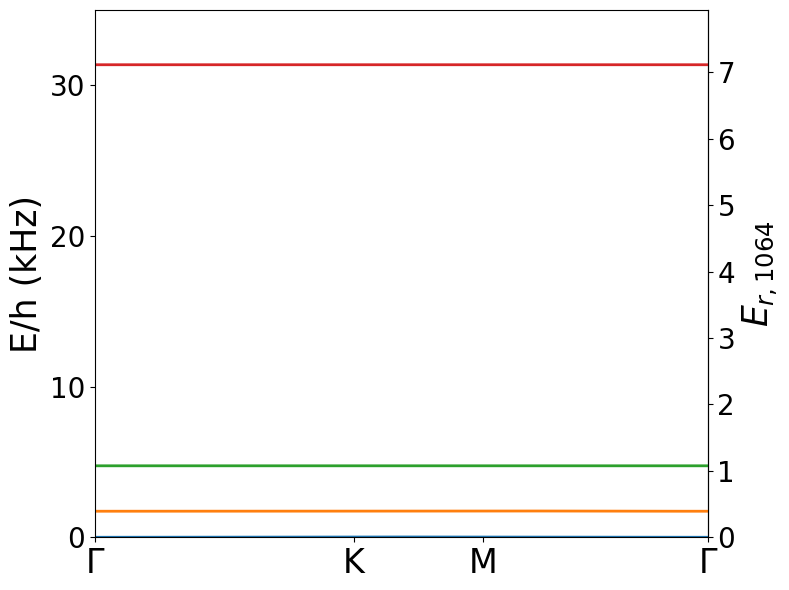

In [15]:
E2kHz = E_unit / E9c.hnobar / 1e3 # conversion factor from natural units to kHz
E_lowest = np.min(e_values)
E_kHz_offset = (e_values - E_lowest) * E2kHz
E_kHz_highest = np.max(E_kHz_offset)
E_plot_kHz = (e_values.transpose() - E_lowest) * E2kHz

fig_E = plt.figure(0, figsize=(8, 6))
fig_E.clf()

ax_E = fig_E.add_subplot(111)
for i in range(bandnum):
    ax_E.plot(xq, E_plot_kHz[i], label = 'Non-interacting' + str(i + bandstart),
              ls = '-', lw = 2)

ryax = ax_E.secondary_yaxis('right', functions = (
    lambda x: x / (E2kHz * 2 * np.pi**2) * E_R_conv,
    lambda x: x * (E2kHz * 2 * np.pi**2) / E_R_conv))
ryax.set_ylabel(rf"$E_{{r,{E_R_axis}}}$", fontsize = 25)
ryax.tick_params(axis = 'y', labelsize = 20)
ax_E.set_ylabel('E/h (kHz)', fontsize = 25)
ax_E.set_xticks(xq[index_points], x_ticklist, fontsize = 24)
f_kHz_yticks = [0, 10, 20, 30]#[0, 5, 10]#
ax_E.set_yticks(f_kHz_yticks, f_kHz_yticks, fontsize = 20)
# ax_E.set_title((rf'$V_{{532}}$ = {V532nom:.3f} kHz (${V532Er:.3f}\ E_{{r, 532}}$), V1064 = {V1064nom:.3f} kHz (${V1064Er:.3f}\ E_{{r, 1064}}$)'
#                 '\n'
#                 rf'AB offset = {float(ABoffset1064nom):.3f} kHz, $\phi_{{12}} = {phi12:.3f}$, $\phi_{{23}} = {phi23:.3f}$'
#                 '\n'
#                 rf'532B1 {B1_rel_int_532:.2f}, 532B3 {B3_rel_int_532:.2f}'))
ax_E.set_xlim(0, xq[-1])
ax_E.set_ylim(0, 35)

# fig_E.suptitle(f'1D q-trajectory, {species}')
fig_E.tight_layout()

band_struc_full_path = Path(thesis_fig_path, "ABCD_band_structure.pdf")
# fig_E.savefig(band_struc_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')

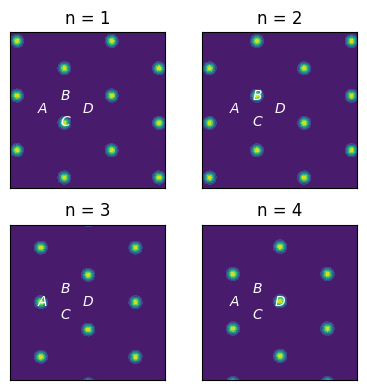

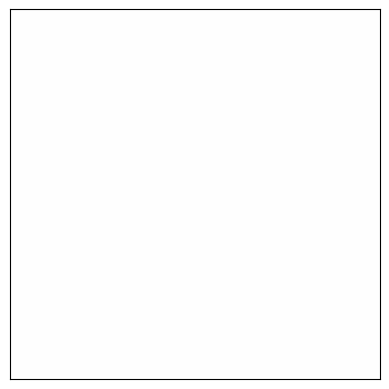

In [16]:
fig_den, axes_den = plt.subplots(2, 2, figsize = (4, 4))
_, _ax = plt.subplots(1, 1)
for i, ax in enumerate(axes_den.flatten()):
    bsc.RealSubPlot([ax, _ax], e_states_ni[i][0], x = np.arange(-6., 6., 0.1), y = np.arange(-6., 6., 0.1))

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"n = {i + 1}")

    ax.text(-2 * np.sqrt(3), 0, r"$A$", size = 10, color = "white",
                ha = "center", va = "center")
    ax.text(-2 * np.sqrt(3) / 2, 1, r"$B$", size = 10, color = "white",
                ha = "center", va = "center")
    ax.text(-2 * np.sqrt(3) / 2, - 1, r"$C$", size = 10, color = "white",
                ha = "center", va = "center")
    ax.text(0, 0, r"$D$", size = 10, color = "white",
                ha = "center", va = "center")

fig_den.tight_layout()
real_full_path = Path(thesis_fig_path, "ABCD_real.pdf")
# fig_den.savefig(real_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')

In [17]:
e_states_ni[6][100].q

IndexError: list index out of range